# 04 — CSP + LDA Baseline

## Objective

Build the first motor-imagery decoding baseline using Common Spatial Patterns (CSP) and Linear Discriminant Analysis (LDA).

The model will be evaluated using leave-one-run-out cross-validation so that each test fold contains an entire recording run that was not used to fit either CSP or LDA.

The initial question is:

> Can a CSP + LDA model distinguish imagined left- from right-fist movement in an unseen run from the same subject?

Subject 1 is used first to verify the modeling and evaluation pipeline before expanding.

### Imports

In [1]:
from pathlib import Path
import sys

import mne
import numpy as np
import pandas as pd

from mne.decoding import CSP

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score

import matplotlib.pyplot as plt

mne.set_log_level("WARNING")

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from neurosignallab.preprocessing import preprocess_subject

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "eegbci"

### Load 1 Subject and separate runs

In [2]:
X, y, metadata = preprocess_subject(
    subject=1,
    data_dir=DATA_DIR
)

groups = metadata["run"].to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Runs:", np.unique(groups))
print("Left trials:", np.sum(y == 0))
print("Right trials:", np.sum(y == 1))

X shape: (45, 64, 481)
y shape: (45,)
Runs: [ 4  8 12]
Left trials: 23
Right trials: 22


### Create CSP and LDA model

In [3]:
csp = CSP(
    n_components=4,
    log=True
)

lda = LinearDiscriminantAnalysis()

model = Pipeline([
    ("csp", csp),
    ("lda", lda)
])

### Create folds, fit models and predict

In [4]:
cv = LeaveOneGroupOut()
results = []

for train_idx, test_idx in cv.split(X, y, groups):

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    held_out_run = groups[test_idx[0]]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "held_out_run": held_out_run,
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "accuracy": accuracy_score(y_test, y_pred)
    })
    
results_df = pd.DataFrame(results)
results_df

,held_out_run,balanced_accuracy,accuracy
0,4,0.741071,0.733333
1,8,0.616071,0.600000
2,12,0.687500,0.666667


### Results Subject 1

In [5]:
print("Mean balanced accuracy:", results_df["balanced_accuracy"].mean())
print("Mean accuracy:", results_df["accuracy"].mean())

Mean balanced accuracy: 0.6815476190476191
Mean accuracy: 0.6666666666666666


## Scale the baseline to Subject 1-5

After verifying the CSP + LDA evaluation pipeline on Subject 1, apply the same fixed preprocessing, model, and leave-one-run-out evaluation procedure to Subjects 1–5.

No model settings are changed between subjects.

### Load and train models for subjects

In [6]:
all_results = []

subjects = range(1,6)

for subject in subjects:

    X, y, metadata = preprocess_subject(
        subject=subject,
        data_dir=DATA_DIR
    )

    groups = metadata["run"].to_numpy()

    for train_idx, test_idx in cv.split(X, y, groups):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        all_results.append({
            "subject": subject,
            "held_out_run": groups[test_idx[0]],
            "balanced_accuracy": balanced_accuracy_score(
                y_test, y_pred
            ),
            "accuracy": accuracy_score(
                y_test, y_pred
            )
        })

all_results_df = pd.DataFrame(all_results)
all_results_df

,subject,held_out_run,balanced_accuracy,accuracy
0,1,4,0.741071,0.733333
1,1,8,0.616071,0.600000
2,1,12,0.687500,0.666667
3,2,4,0.803571,0.800000
4,2,8,0.794643,0.800000
5,2,12,0.785714,0.800000
6,3,4,0.651786,0.666667
7,3,8,0.500000,0.466667
8,3,12,0.401786,0.400000
9,4,4,0.500000,0.533333


### Results, Subject 1-5

In [7]:
subject_results = (
    all_results_df
    .groupby("subject")[["balanced_accuracy", "accuracy"]]
    .mean()
)

subject_results

,balanced_accuracy,accuracy
subject,,
1,0.681548,0.666667
2,0.794643,0.800000
3,0.517857,0.511111
4,0.491071,0.488889
5,0.541667,0.555556


### Initial multi-subject result

The fixed CSP + LDA baseline showed substantial variability across the first five subjects.

Subjects 1 and 2 achieved mean balanced accuracies of approximately 0.68 and 0.79 respectively, indicating above-chance within-subject decoding across held-out runs.

Subjects 3–5 performed much closer to chance, with mean balanced accuracies of approximately 0.52, 0.49, and 0.54.

The run-level results also varied within some subjects. This suggests that motor-imagery decoding performance is not uniform across individuals or recordings.


### Scale to Subjects 1-20, then full cohort

In [8]:
all_results = []

subjects = range(1,110)

for subject in subjects:

    X, y, metadata = preprocess_subject(
        subject=subject,
        data_dir=DATA_DIR
    )

    groups = metadata["run"].to_numpy()

    for train_idx, test_idx in cv.split(X, y, groups):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        all_results.append({
            "subject": subject,
            "held_out_run": groups[test_idx[0]],
            "balanced_accuracy": balanced_accuracy_score(
                y_test, y_pred
            ),
            "accuracy": accuracy_score(
                y_test, y_pred
            )
        })

all_results_df = pd.DataFrame(all_results)
all_results_df

/Users/heihei/Desktop/neurosignallab/src/neurosignallab/preprocessing.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_run = mne.io.read_raw_edf(
/Users/heihei/Desktop/neurosignallab/src/neurosignallab/preprocessing.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_run = mne.io.read_raw_edf(
/Users/heihei/Desktop/neurosignallab/src/neurosignallab/preprocessing.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_run = mne.io.read_raw_edf(


,subject,held_out_run,balanced_accuracy,accuracy
0,1,4,0.741071,0.733333
1,1,8,0.616071,0.600000
2,1,12,0.687500,0.666667
3,2,4,0.803571,0.800000
4,2,8,0.794643,0.800000
...,...,...,...,...
322,108,8,0.669643,0.666667
323,108,12,0.678571,0.666667
324,109,4,0.500000,0.466667
325,109,8,0.455357,0.466667


### Results Subjects

In [9]:
subject_results = (
    all_results_df
    .groupby("subject")[["balanced_accuracy", "accuracy"]]
    .mean()
)

subject_results

,balanced_accuracy,accuracy
subject,,
1,0.681548,0.666667
2,0.794643,0.800000
3,0.517857,0.511111
4,0.491071,0.488889
5,0.541667,0.555556
...,...,...
105,0.574405,0.577778
106,0.604167,0.600000
107,0.553571,0.555556


### Plot subjects accuracy

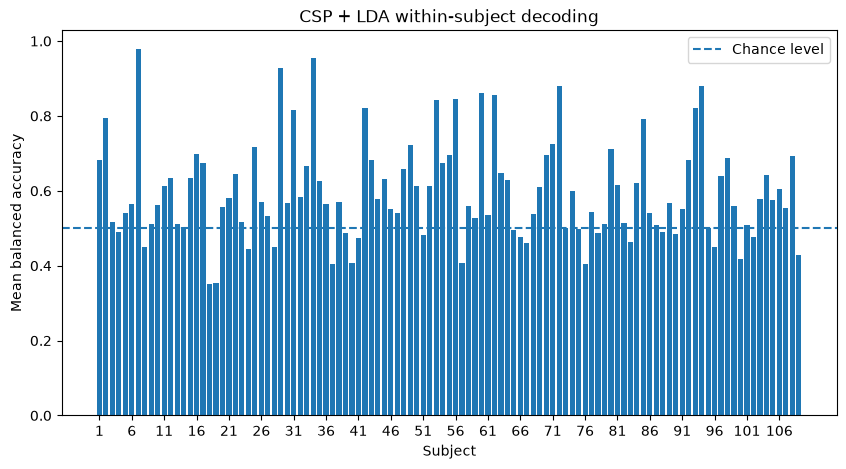

In [10]:
plt.figure(figsize=(10, 5))

plt.bar(
    subject_results.index,
    subject_results["balanced_accuracy"]
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Chance level"
)

plt.xlabel("Subject")
plt.ylabel("Mean balanced accuracy")
plt.title("CSP + LDA within-subject decoding")

plt.xticks(range(1, 110, 5))

plt.legend()
plt.show()

### Save full cohort til csv

In [ ]:
folds_path = PROJECT_ROOT / "results" / "csp_lda_within_subject_folds.csv"
summary_path = PROJECT_ROOT / "results" / "csp_lda_within_subject_summary.csv"

if not folds_path.exists():
    all_results_df.to_csv(folds_path, index=False)

if not summary_path.exists():
    subject_results.to_csv(summary_path)

### Summary of results, full cohort

In [11]:
print(
    "Mean balanced accuracy:",
    subject_results["balanced_accuracy"].mean()
)

print(
    "Median balanced accuracy:",
    subject_results["balanced_accuracy"].median()
)

print(
    "Minimum balanced accuracy:",
    subject_results["balanced_accuracy"].min()
)

print(
    "Maximum balanced accuracy:",
    subject_results["balanced_accuracy"].max()
)

run_results = all_results_df.groupby("held_out_run")["balanced_accuracy"].mean()
run_results

Mean balanced accuracy: 0.5972835056550654
Median balanced accuracy: 0.5684523809523809
Minimum balanced accuracy: 0.3511904761904762
Maximum balanced accuracy: 0.9791666666666666


held_out_run
4     0.588911
8     0.595386
12    0.607554
Name: balanced_accuracy, dtype: float64

## Summary

The fixed CSP + LDA baseline was evaluated across all 109 subjects using leave-one-run-out cross-validation.

Each subject was modeled independently, with CSP and LDA refitted inside every training fold. The held-out run therefore did not participate in fitting either the spatial filters or the classifier.

Across the 109 subjects, mean balanced accuracy was 0.597 and median balanced accuracy was 0.568. Subject-level performance varied substantially, ranging from 0.351 to 0.979.

Mean balanced accuracy was similar across the three held-out runs:

- Run 4: 0.589
- Run 8: 0.595
- Run 12: 0.608

There was therefore no large systematic performance difference between the three recording runs.

The results show substantial inter-subject variability in within-subject motor-imagery decoding. Some subjects could be decoded considerably above chance using the fixed CSP + LDA baseline, while others remained near or below chance.

The difference could all be cause by reasons we cannot determine: 

- Strength of sensorimotor ERD/ERS
- Spatial pattern consistency
- Recording quality
- Participant task performance
- Individual physiology
- Run-to-run variability


These results establish the first within-subject baseline. They do not establish statistical significance for individual subjects and do not demonstrate generalization to previously unseen subjects.